# K-Fold Cross Validation

## Step-by-step

1. **Data Splitting**: The dataset is divided into $k$ equal folds.  
2. **Model Training**: For each iteration (a total of $k$ times):  
   - $k-1$ folds are used for training.  
   - The remaining fold is used for testing the model.  
3. **Error Calculation**: After $k$ iterations, we obtain *k* performance metrics (e.g., accuracy, MSE, etc.).  
4. **Final Evaluation**: The final model performance is determined by taking the average of all $k$ metric scores.

## How does K-Fold cross validation work?

Folds:

1. [V][ ][ ][ ][ ][ ][ ][ ][ ][ ] -> Metrics(V)
2. [ ][V][ ][ ][ ][ ][ ][ ][ ][ ] -> Metrics(V)
3. [ ][ ][V][ ][ ][ ][ ][ ][ ][ ] -> Metrics(V)
4. [ ][ ][ ][V][ ][ ][ ][ ][ ][ ] -> Metrics(V)
5. [ ][ ][ ][ ][V][ ][ ][ ][ ][ ] -> Metrics(V)
6. [ ][ ][ ][ ][ ][V][ ][ ][ ][ ] -> Metrics(V)
7. [ ][ ][ ][ ][ ][ ][V][ ][ ][ ] -> Metrics(V)
8. [ ][ ][ ][ ][ ][ ][ ][V][ ][ ] -> Metrics(V)
9. [ ][ ][ ][ ][ ][ ][ ][ ][V][ ] -> Metrics(V)
10. [ ][ ][ ][ ][ ][ ][ ][ ][ ][V] -> Metrics(V)

V - validation data\
[ ] - training data\
Metrics(V) - score

Final score = mean([Metrics(V)])

## Load the libraries

In [1]:
suppressMessages(library(tidyverse))
suppressMessages(library(ggplot2))
suppressMessages(library(caret))
suppressMessages(library(e1071))

## Load data

In [2]:
df <- read_csv('../00_data/Social_Network_ads.csv', show_col_types = FALSE)
head(df)

Age,EstimatedSalary,Purchased
<dbl>,<dbl>,<dbl>
19,19000,0
35,20000,0
26,43000,0
27,57000,0
19,76000,0
27,58000,0


In [3]:
dim(df)

[1] 400   3

In [4]:
df$Purchased <- factor(df$Purchased)

In [5]:
glimpse(df)

Rows: 400
Columns: 3
$ Age             <dbl> 19, 35, 26, 27, 19, 27, 27, 32, 25, 35, 26, 26, 20, 32…
$ EstimatedSalary <dbl> 19000, 20000, 43000, 57000, 76000, 58000, 84000, 15000…
$ Purchased       <fct> 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, …


## Splitting the dataset into the Training set and Test set

In [6]:
set.seed(123)

train_data <- df |> slice_sample(prop = 0.75)
test_data <- df |> anti_join(train_data, by=colnames(df))

## Fit and evaluate the model

In [7]:
classifier <- svm(Purchased ~ ., train_data, type = "C-classification", kernel = "radial", scale = TRUE)
y_pred <- predict(classifier, newdata = test_data[-3], scale = TRUE)
# accuracy
mean(test_data$Purchased == y_pred)

[1] 0.9047619

## Apply k-Fold cross validation

In [8]:
folds <- createFolds(train_data$Purchased, k = 10)
cv <- lapply(folds, function(x){
    training_fold <- train_data[-x, ]
    test_fold <- train_data[x, ]
    classifier <- svm(Purchased ~ ., training_fold, type = "C-classification", kernel = "radial", scale = TRUE)
    y_pred <- predict(classifier, newdata = test_fold[-3], scale = TRUE)
    # accuracy
    mean(test_fold$Purchased == y_pred)
})

cv

$Fold01
[1] 0.9333333

$Fold02
[1] 0.9354839

$Fold03
[1] 0.862069

$Fold04
[1] 0.9

$Fold05
[1] 0.9

$Fold06
[1] 0.9

$Fold07
[1] 0.9

$Fold08
[1] 0.9333333

$Fold09
[1] 0.8666667

$Fold10
[1] 0.8666667

In [9]:
# mean accuracy
mean(as.numeric(cv))

[1] 0.8997553

## Grid search (hyperparameter tuning) using `train()` func

In [10]:
# cv
train_control <- trainControl(method = "cv", number = 10)
# params
tune_grid <- expand.grid(C = seq(0.1, 1, 0.1), sigma = 2^(-3:3))
# tuning
svm_model <- train(form = Purchased ~ .,
                   data = train_data,
                   method = "svmRadial",
                   trControl = train_control,
                   tuneGrid = tune_grid,
                   preProcess = c("center", "scale") # scaling
                )

print("Best CVM model:")
print(svm_model$bestTune)

print("Mean score:")
print(mean(svm_model$results$Accuracy))

y_pred <- predict(svm_model, newdata = test_data[-3])
# accuracy
print("Accuracy of the best mode on test set:")
print(mean(test_data$Purchased == y_pred))

[1] "Best CVM model:"
   sigma C
68     2 1
[1] "Mean score:"
[1] 0.9018951
[1] "Accuracy of the best mode on test set:"
[1] 0.9047619


## Combining grid search (hyperparameter tuning) and Cross Validation using `tune()` func

In [11]:
# params configurations
kernels <- list(linear = list(kernel = 'linear',
                             params = list(cost = seq(0.1, 1, 0.1))),
                redial = list(kernel = 'radial',
                             params = list(cost = seq(0.1, 1, 0.1), 
                                           gamma = c(1, 0.1, 0.01))),
                poly = list(kernel = 'poly',
                           params = list(cost = seq(0.1, 1, 0.1), 
                                         gamma = c(1, 0.1, 0.01),
                                         degree = 2:4))
)

best_models <- lapply(kernels, function(x){
    set.seed(0)
    # run best hyperparameters searching
    tuned <- tune(
      'svm',
      Purchased ~ .,
      data = train_data,
      kernel = x$kernel,
      scale = TRUE, # feature scaling
      ranges = x$params,
      tunecontrol = tune.control(cross = 10) 
    )
    best_model <- tuned$best.model # the best kernel SVM
    # evaluate on the test set
    y_pred <- predict(best_model, newdata = test_data[-3], scale = TRUE)
    accuracy <- mean(test_data$Purchased == y_pred)
    list(kernel = x$kernel,
         best.params = tuned$best.parameters,
         best.accuracy=accuracy,
         best.model=best_model)
})

best_model <- best_models[[which.max(sapply(best_models, function(x) x$best.accuracy))]]

print(paste0('Accuracy (', best_model$kernel,' kernel): ', best_model$best.accuracy))

[1] "Accuracy (radial kernel): 0.904761904761905"


In [12]:
# best params for radial kernel
best_model$best.params

,cost,gamma
,<dbl>,<dbl>
9,0.9,1


In [13]:
# confusion matrix on test set
table(test_data$Purchased, predict(best_model$best.model, newdata = test_data[-3], scale = TRUE))

   
     0  1
  0 48  5
  1  3 28

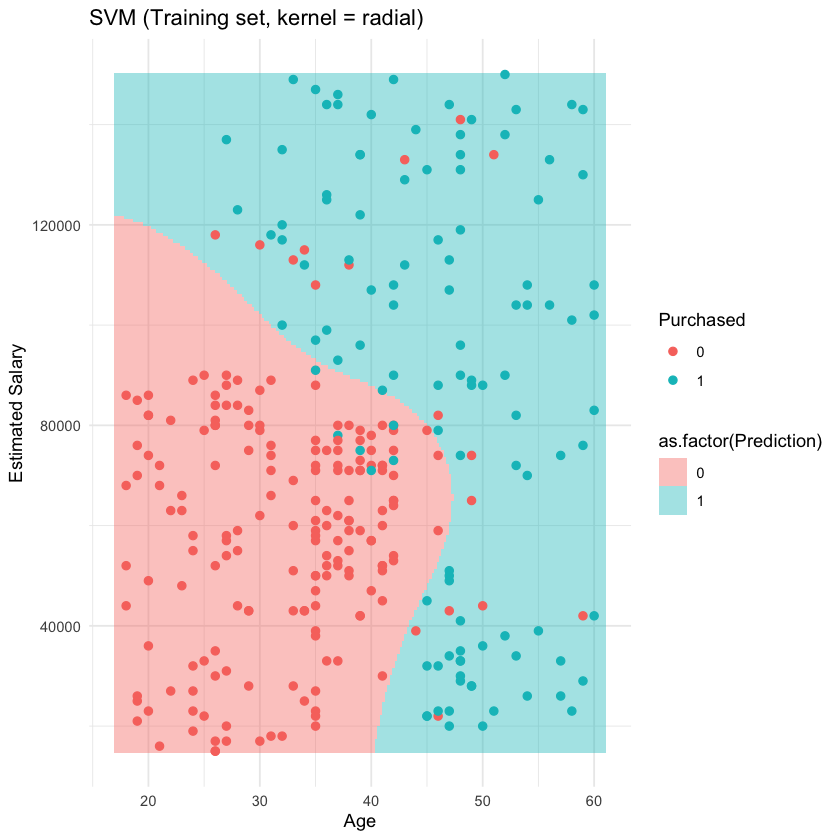

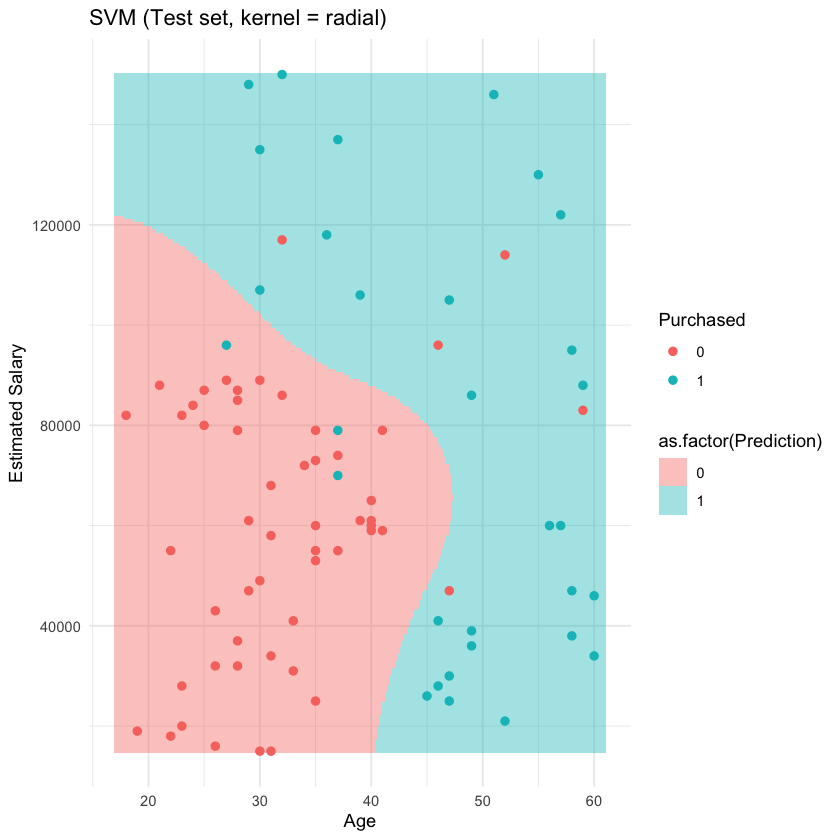

In [14]:
svm_pred_boundary <- function(model, df_test, name){
        X1 <- seq(min(df_test$Age) - 1, max(df_test$Age) + 1, length.out = 200)
        X2 <- seq(min(df_test$EstimatedSalary) - 1, max(df_test$EstimatedSalary) + 1, length.out = 200)
        grid <- expand.grid(X1, X2)
        colnames(grid) <- c('Age', 'EstimatedSalary')
        grid$Prediction <- predict(model$best.model, newdata = grid, scale = TRUE)
        
        print(ggplot() +
            geom_tile(data=grid, aes(x = Age, y = EstimatedSalary, fill = as.factor(Prediction)), alpha=0.4) +
            geom_point(df_test, mapping=aes(x = Age, y = EstimatedSalary, colour = Purchased), size=2) +
            #scale_fill_manual(values = c("red", "blue"), name = "Prediction") +
            #scale_color_manual(values = c("red", "blue"), name = "Purchased") +
            labs(title = paste0("SVM (", name, ", kernel = ", model$kernel, ")"), x = "Age", y = "Estimated Salary") +
            theme_minimal())
    }
    
svm_pred_boundary(best_model, train_data, 'Training set')
svm_pred_boundary(best_model, test_data, 'Test set')